In [ ]:
import os, re, glob, math, random, warnings, time, gc
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter, defaultdict
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")
if device.type == 'cuda': 
    print(f"GPU name  : {torch.cuda.get_device_name(0)}")


Running on: cuda
GPU name  : Tesla P100-PCIE-16GB


In [2]:
!pip install -q torchsummary

In [ ]:
# Uninstall current broken torch
!pip uninstall torch torchvision torchaudio -y

!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124 -q

## Hyperparameters & Config

In [ ]:
FRAMES_DIR = '/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset/embryo_dataset'
LABELS_DIR = '/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset_annotations/embryo_dataset_annotations'

assert os.path.isdir(FRAMES_DIR), f"FRAMES_DIR missing: {FRAMES_DIR}"
assert os.path.isdir(LABELS_DIR), f"LABELS_DIR missing: {LABELS_DIR}"
print(f"Frames : {FRAMES_DIR}")
print(f"Labels : {LABELS_DIR}")

DEV_STAGES = ['tPB2', 'tPNa', 'tPNf', 't2', 't3', 't4', 't5', 't6', 't7', 't8', 't9+', 'tM',  'tSB', 'tB',  'tEB', 'tHB']

SEQ_LEN = 10     
LSTM_UNITS = 256    
NUM_LAYERS = 3      
DROP_RATE = 0.3    
CNN_OUT_DIM = 1280  
NUM_VIDEOS = 500   
FRAME_STRIDE = 1     
MAX_FRAMES = 2000  
CNN_BATCH = 64    
TRAIN_BS = 128
N_WORKERS = 4
LEARN_RATE = 1e-3
L2_REG = 1e-5
ORD_WEIGHT = 2.0    
MAX_EPOCHS = 20
EARLY_STOP = 5
RNG_SEED = 42

random.seed(RNG_SEED)
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RNG_SEED)


Frames : /kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset/embryo_dataset
Labels : /kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset_annotations/embryo_dataset_annotations

All config loaded ✓


## Dataset Exploration

In [ ]:
print("=== FRAMES DIR ===")
vid_dirs = sorted(os.listdir(FRAMES_DIR))
print(f"  Total video folders : {len(vid_dirs)}")
if vid_dirs:
    ex_dir = vid_dirs[0]
    ex_path = os.path.join(FRAMES_DIR, ex_dir)
    print(f"\n  First folder: {ex_dir}/")
    for f in sorted(os.listdir(ex_path))[:8]:
        print(f" {f}")

print("\n=== LABELS DIR ===")
csv_list = sorted(glob.glob(os.path.join(LABELS_DIR, '*.csv')))
print(f"  Total CSV files : {len(csv_list)}")
if csv_list:
    ex_csv = csv_list[0]
    print(f"\n  Example: {Path(ex_csv).name}")
    df_ex = pd.read_csv(ex_csv, header=None, names=['stage', 'frame_start', 'frame_end'])
    print(df_ex.head(10))


=== FRAMES DIR ===
  Total video folders : 704

  First folder: AA83-7/
    D2013.01.28_S0717_I132_WELL7_RUN1.jpeg
    D2013.01.28_S0717_I132_WELL7_RUN10.jpeg
    D2013.01.28_S0717_I132_WELL7_RUN100.jpeg
    D2013.01.28_S0717_I132_WELL7_RUN101.jpeg
    D2013.01.28_S0717_I132_WELL7_RUN102.jpeg
    D2013.01.28_S0717_I132_WELL7_RUN103.jpeg
    D2013.01.28_S0717_I132_WELL7_RUN104.jpeg
    D2013.01.28_S0717_I132_WELL7_RUN105.jpeg

=== LABELS DIR ===
  Total CSV files : 704

  Example: AA83-7_phases.csv
  stage  frame_start  frame_end
0  tPB2            5         24
1  tPNa           25         88
2  tPNf           89         97
3    t2           98        171
4    t3          172        177
5    t4          178        191
6    t5          192        241
7    t6          242        256
8    t7          257        276
9    t8          277        286


## Data

In [ ]:
def parse_frame_idx(filename):
    stem = Path(filename).stem
    hit = re.search(r'RUN(\d+)', stem, re.IGNORECASE)
    if hit:
        return int(hit.group(1))
    nums = re.findall(r'(\d+)', stem)
    return int(nums[-1]) if nums else None


def read_phase_labels(labels_dir):
    annot_map = {}
    for csv_path in sorted(glob.glob(os.path.join(labels_dir, '*.csv'))):
        vname = Path(csv_path).stem
        for suf in ['_phases', '_phase', '_annotations', '_annot', '_labels']:
            if vname.endswith(suf):
                vname = vname[:-len(suf)]
                break
        try:
            df = pd.read_csv(csv_path, header=None, names=['stage', 'frame_start', 'frame_end'])
            df['stage'] = df['stage'].astype(str).str.strip()
            df['frame_start'] = pd.to_numeric(df['frame_start'], errors='coerce')
            df['frame_end'] = pd.to_numeric(df['frame_end'],   errors='coerce')
            df = df.dropna(subset=['stage', 'frame_start', 'frame_end'])
            df['frame_start'] = df['frame_start'].astype(int)
            df['frame_end'] = df['frame_end'].astype(int)
            if len(df) > 0:
                annot_map[vname] = df
        except Exception as err:
            print(f"  WARN [{Path(csv_path).name}]: {err}")
    print(f"Loaded annotations for {len(annot_map)} videos")
    print(f"  Sample keys: {sorted(annot_map.keys())[:5]}")
    return annot_map


def lookup_phase(fnum, ann_df):
    for _, row in ann_df.iterrows():
        if row['frame_start'] <= fnum <= row['frame_end']:
            return str(row['stage']).strip()
    return None


def find_annotation(vid_name, annot_map):
    if vid_name in annot_map:
        return annot_map[vid_name]
    vl = vid_name.lower()
    for k in annot_map:
        if k.lower() == vl:
            return annot_map[k]
    for k in annot_map:
        if k.lower() in vl or vl in k.lower():
            return annot_map[k]
    return None


def collect_frame_data(frames_dir, annot_map, frame_stride=1, max_per_video=2000, num_videos=None):
    records = []
    no_annot, no_label = 0, 0

    all_vdirs = sorted([d for d in os.listdir(frames_dir) if os.path.isdir(os.path.join(frames_dir, d))])
    if num_videos and len(all_vdirs) > num_videos:
        random.seed(RNG_SEED)
        all_vdirs = sorted(random.sample(all_vdirs, num_videos))

    print(f"Scanning {len(all_vdirs)} video folders …")
    for vd in all_vdirs:
        vpath  = os.path.join(frames_dir, vd)
        ann_df = find_annotation(vd, annot_map)
        if ann_df is None:
            no_annot += 1
            continue

        img_files = sorted(
            glob.glob(os.path.join(vpath, '*.jpg'))  +
            glob.glob(os.path.join(vpath, '*.jpeg')) +
            glob.glob(os.path.join(vpath, '*.png')))
        if not img_files:
            img_files = sorted(
                glob.glob(os.path.join(vpath, '**', '*.jpg'),   recursive=True) +
                glob.glob(os.path.join(vpath, '**', '*.jpeg'),  recursive=True) +
                glob.glob(os.path.join(vpath, '**', '*.png'),   recursive=True))

        frame_data = []
        for fp in img_files:
            fi = parse_frame_idx(os.path.basename(fp))
            if fi is not None:
                frame_data.append((fp, fi))
        frame_data.sort(key=lambda x: x[1])
        frame_data = frame_data[::frame_stride]

        if len(frame_data) > max_per_video:
            idx = np.linspace(0, len(frame_data)-1, max_per_video, dtype=int)
            frame_data = [frame_data[i] for i in idx]

        for img_path, fnum in frame_data:
            lbl = lookup_phase(fnum, ann_df)
            if lbl is not None:
                records.append((img_path, lbl, vd, fnum))
            else:
                no_label += 1

    print(f"\nTotal samples  : {len(records):,}")
    print(f"  No annotation : {no_annot} videos skipped")
    print(f"  No label      : {no_label} frames skipped")
    return records

annot_map = read_phase_labels(LABELS_DIR)
raw_data = collect_frame_data(FRAMES_DIR, annot_map, frame_stride=FRAME_STRIDE, max_per_video=MAX_FRAMES, num_videos=NUM_VIDEOS)


Loaded annotations for 704 videos
  Sample keys: ['AA83-7', 'AAL839-6', 'AB028-6', 'AB91-1', 'AC264-1']
Scanning 500 video folders …

Total samples  : 212,224
  No annotation : 0 videos skipped
  No label      : 30820 frames skipped


Stages found (16): ['t2', 't3', 't4', 't5', 't6', 't7', 't8', 't9+', 'tB', 'tEB', 'tHB', 'tM', 'tPB2', 'tPNa', 'tPNf', 'tSB']

Stage distribution:
      t2: 20,541
      t3:  3,821
      t4: 20,488
      t5:  5,949
      t6:  5,735
      t7:  7,927
      t8: 23,280
     t9+: 36,742
      tB:  7,641
     tEB: 14,068
     tHB:     87
      tM: 12,434
    tPB2:  6,020
    tPNa: 30,493
    tPNf:  4,831
     tSB: 12,167


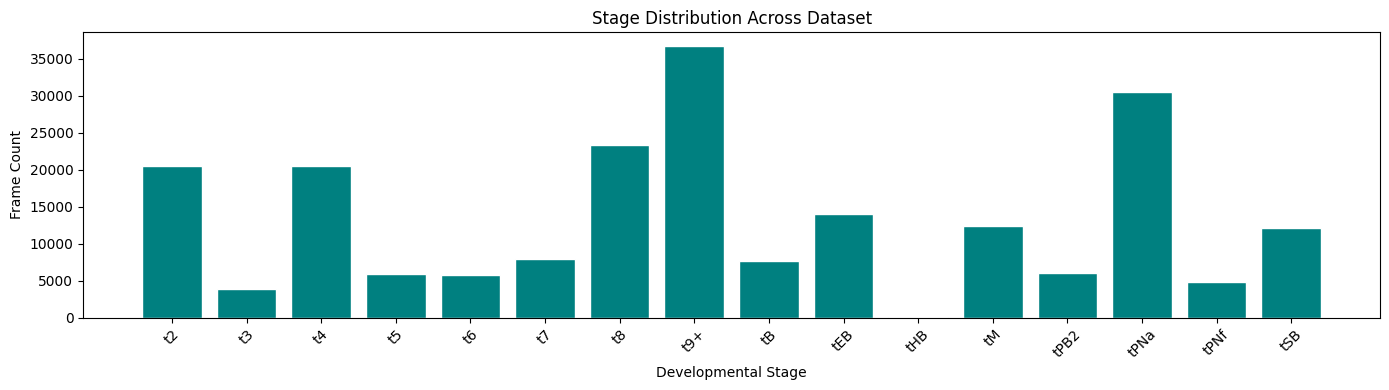


Ordinal rank per class index:
      t2  →  rank 3
      t3  →  rank 4
      t4  →  rank 5
      t5  →  rank 6
      t6  →  rank 7
      t7  →  rank 8
      t8  →  rank 9
     t9+  →  rank 10
      tB  →  rank 13
     tEB  →  rank 14
     tHB  →  rank 15
      tM  →  rank 11
    tPB2  →  rank 0
    tPNa  →  rank 1
    tPNf  →  rank 2
     tSB  →  rank 12

Class weights: [0.592 0.605 0.592 0.593 0.594 0.592 0.592 0.592 0.592 0.592 7.099 0.592
 0.593 0.592 0.597 0.592]


In [ ]:
unique_stages = sorted(set(r[1] for r in raw_data))
cls2idx = {s: i for i, s in enumerate(unique_stages)}
idx2cls = {i: s for s, i in cls2idx.items()}
N_CLASSES = len(cls2idx)
print(f"Stages found ({N_CLASSES}): {unique_stages}\n")

stage_counts = Counter(r[1] for r in raw_data)
print("Stage distribution:")
for s in unique_stages:
    print(f"  {s:>6s}: {stage_counts[s]:>6,}")


fig, ax = plt.subplots(figsize=(14, 4))
cnt_arr = np.array([stage_counts[s] for s in unique_stages], dtype=float)
ax.bar(unique_stages, cnt_arr, color='teal', edgecolor='white')
ax.set_xlabel('Developmental Stage')
ax.set_ylabel('Frame Count')
ax.set_title('Stage Distribution Across Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

stage_ranks = torch.zeros(N_CLASSES)
for rank, stage in enumerate(DEV_STAGES):
    if stage in cls2idx:
        stage_ranks[cls2idx[stage]] = float(rank)
stage_ranks = stage_ranks.to(device)
print("\nOrdinal rank per class index:")
for ci in range(N_CLASSES):
    print(f"  {idx2cls[ci]:>6s}  →  rank {int(stage_ranks[ci].item())}")

beta = 0.999
eff_num = 1.0 - np.power(beta, cnt_arr)
raw_w = (1.0 - beta) / eff_num
norm_w = raw_w / raw_w.sum() * N_CLASSES
cls_weights = torch.tensor(norm_w, dtype=torch.float32).to(device)
print(f"\nClass weights: {cls_weights.cpu().numpy().round(3)}")

## CNN Feature Extraction (MobileNetV2)

In [ ]:
cnn_encoder = models.mobilenet_v2(weights='IMAGENET1K_V1')
cnn_encoder.classifier = nn.Identity()   
cnn_encoder = cnn_encoder.to(device)
cnn_encoder.eval()
for p in cnn_encoder.parameters():
    p.requires_grad = False
print(f"Backbone ready — output dim: {CNN_OUT_DIM}")

img_pipeline = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std =[0.229, 0.224, 0.225]),
])

total_frames = len(raw_data)
print(f"\nExtracting features for {total_frames:,} frames (CNN batch={CNN_BATCH}) …")
frame_feats = {}   
all_img_paths = [r[0] for r in raw_data]
t_start = time.time()

for start in range(0, len(all_img_paths), CNN_BATCH):
    chunk = all_img_paths[start:start + CNN_BATCH]
    imgs, valid_paths = [], []
    for p in chunk:
        try:
            img = Image.open(p).convert('RGB')
            imgs.append(img_pipeline(img))
            valid_paths.append(p)
        except (OSError, IOError, SyntaxError):
            continue
    if imgs:
        batch_t = torch.stack(imgs).to(device)
        with torch.no_grad():
            fvecs = cnn_encoder(batch_t)
        for p, fv in zip(valid_paths, fvecs):
            frame_feats[p] = fv.cpu()
    if (start // CNN_BATCH) % 100 == 0:
        done = min(start + CNN_BATCH, total_frames)
        print(f"  {done:,}/{total_frames:,} processed")

print(f"\nDone — {len(frame_feats):,} vectors in {time.time()-t_start:.1f}s")
print(f"Vector shape: {next(iter(frame_feats.values())).shape}")

del cnn_encoder
torch.cuda.empty_cache()
gc.collect()

Initialising MobileNetV2 backbone …


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 143MB/s]


Backbone ready — output dim: 1280

Extracting features for 212,224 frames (CNN batch=64) …
  64/212,224 processed
  6,464/212,224 processed
  12,864/212,224 processed
  19,264/212,224 processed
  25,664/212,224 processed
  32,064/212,224 processed
  38,464/212,224 processed
  44,864/212,224 processed
  51,264/212,224 processed
  57,664/212,224 processed
  64,064/212,224 processed
  70,464/212,224 processed
  76,864/212,224 processed
  83,264/212,224 processed
  89,664/212,224 processed
  96,064/212,224 processed
  102,464/212,224 processed
  108,864/212,224 processed
  115,264/212,224 processed
  121,664/212,224 processed
  128,064/212,224 processed
  134,464/212,224 processed
  140,864/212,224 processed
  147,264/212,224 processed
  153,664/212,224 processed
  160,064/212,224 processed
  166,464/212,224 processed
  172,864/212,224 processed
  179,264/212,224 processed
  185,664/212,224 processed
  192,064/212,224 processed
  198,464/212,224 processed
  204,864/212,224 processed
  211,

In [ ]:
# FEAT_CACHE = '/kaggle/working/frame_feats.pt'
# torch.save(frame_feats, FEAT_CACHE)
# print(f"Saved {len(frame_feats):,} feature vectors to {FEAT_CACHE}")

Saved 212,224 feature vectors to /kaggle/working/frame_feats.pt


In [ ]:
FEAT_CACHE = '/kaggle/working/frame_feats.pt'
frame_feats = torch.load(FEAT_CACHE, map_location='cpu')
print(f"Loaded {len(frame_feats):,} feature vectors from cache")
print(f"Vector shape: {next(iter(frame_feats.values())).shape}")

## Sliding-Window Sequence Construction

In [ ]:
vid_frame_map = defaultdict(list)
for img_path, lbl, vd, fnum in raw_data:
    if img_path in frame_feats:
        vid_frame_map[vd].append((img_path, fnum, lbl))

for vd in vid_frame_map:
    vid_frame_map[vd].sort(key=lambda x: x[1])   

print(f"Videos with features : {len(vid_frame_map)}")
print("Frames per video (first 5):", end=' ')
for v in list(vid_frame_map.keys())[:5]:
    print(f"{v}={len(vid_frame_map[v])}", end='  ')
print()


def make_windows(vid_frame_dict, win_len):
    seq_pool = []
    skipped = 0
    for vname, frames in vid_frame_dict.items():
        if len(frames) < win_len:
            skipped += 1
            continue
        for i in range(len(frames) - win_len + 1):
            window = frames[i:i + win_len]
            paths = [f[0] for f in window]
            target = window[-1][2]
            seq_pool.append((vname, paths, target))
    print(f"Built {len(seq_pool):,} sequences  (window={win_len})")
    if skipped:
        print(f"{skipped} videos had < {win_len} frames and were skipped")
    return seq_pool


def split_by_video(seq_pool, val_frac=0.15, test_frac=0.15):
    by_video = defaultdict(list)
    for seq in seq_pool:
        by_video[seq[0]].append(seq)

    vid_names = sorted(by_video.keys())
    random.seed(RNG_SEED)
    random.shuffle(vid_names)

    n = len(vid_names)
    n_test = max(1, int(n * test_frac))
    n_val = max(1, int(n * val_frac))

    te_vids = vid_names[:n_test]
    va_vids = vid_names[n_test:n_test + n_val]
    tr_vids = vid_names[n_test + n_val:]

    tr_seqs = [s for v in tr_vids for s in by_video[v]]
    va_seqs = [s for v in va_vids for s in by_video[v]]
    te_seqs = [s for v in te_vids for s in by_video[v]]
    print(f"\nVideo-wise split:")
    print(f"  Train : {len(tr_seqs):>7,} seqs  ({len(tr_vids)} videos)")
    print(f"  Val   : {len(va_seqs):>7,} seqs  ({len(va_vids)} videos)")
    print(f"  Test  : {len(te_seqs):>7,} seqs  ({len(te_vids)} videos)")
    return tr_seqs, va_seqs, te_seqs

seq_pool = make_windows(vid_frame_map, SEQ_LEN)
tr_seqs, va_seqs, te_seqs = split_by_video(seq_pool)

Videos with features : 500
Frames per video (first 5): AA83-7=281  AAL839-6=544  AB91-1=387  AC264-1=223  AG274-2=555  
Built 207,724 sequences  (window=10)

Video-wise split:
  Train : 147,040 seqs  (350 videos)
  Val   :  29,661 seqs  (75 videos)
  Test  :  31,023 seqs  (75 videos)


## DataLoaders

In [ ]:
class FrameSeqDataset(Dataset):
    def __init__(self, seq_list, feats_dict, cls2idx):
        self.seq_list = seq_list
        self.feats = feats_dict
        self.cls2idx = cls2idx

    def __len__(self):
        return len(self.seq_list)

    def __getitem__(self, idx):
        vname, paths, stage = self.seq_list[idx]
        feat_seq = torch.stack([self.feats[p] for p in paths])
        return feat_seq, self.cls2idx[stage]


def build_dataloaders(tr_seqs, va_seqs, te_seqs, feats, cls2idx, bs=128):
    tr_ds = FrameSeqDataset(tr_seqs, feats, cls2idx)
    va_ds = FrameSeqDataset(va_seqs, feats, cls2idx)
    te_ds = FrameSeqDataset(te_seqs, feats, cls2idx)

    # Oversample minority stages during training
    tr_stage_cnt = Counter(s[2] for s in tr_seqs)
    sample_wts = [1.0 / tr_stage_cnt[s[2]] for s in tr_seqs]
    sampler = WeightedRandomSampler(sample_wts, num_samples=len(tr_seqs), replacement=True)

    kw = dict(num_workers=N_WORKERS, pin_memory=True)
    tr_loader = DataLoader(tr_ds, batch_size=bs, sampler=sampler, **kw)
    va_loader = DataLoader(va_ds, batch_size=bs, shuffle=False, **kw)
    te_loader = DataLoader(te_ds, batch_size=bs, shuffle=False, **kw)

    print(f"DataLoaders ready (bs={bs}):")
    print(f"  Train: {len(tr_loader)} batches | " f"Val: {len(va_loader)} batches | " f"Test: {len(te_loader)} batches")
    return tr_loader, va_loader, te_loader


tr_loader, va_loader, te_loader = build_dataloaders(tr_seqs, va_seqs, te_seqs, frame_feats, cls2idx, bs=TRAIN_BS)

DataLoaders ready (bs=128):
  Train: 1149 batches | Val: 232 batches | Test: 243 batches


## LSTM 

In [ ]:
class PhaseClassifier(nn.Module):
    def __init__(self, in_dim, lstm_units, num_layers, n_classes, drop_rate=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=in_dim,
            hidden_size=lstm_units,
            num_layers=num_layers,
            batch_first=True,
            dropout=drop_rate if num_layers > 1 else 0.0
        )
        self.head = nn.Sequential(
            nn.Dropout(drop_rate),
            nn.Linear(lstm_units, n_classes)
        )

    def forward(self, x):
        out, _ = self.lstm(x)       
        last = out[:, -1, :]      
        return self.head(last)      


model = PhaseClassifier(
    in_dim=CNN_OUT_DIM,
    lstm_units=LSTM_UNITS,
    num_layers=NUM_LAYERS,
    n_classes=N_CLASSES,
    drop_rate=DROP_RATE
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal params : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")
print("\nLayer-wise breakdown:")
for name, p in model.named_parameters():
    print(f"  {name:>40s}  {str(list(p.shape)):>20s}  {p.numel():>10,}")

PhaseClassifier(
  (lstm): LSTM(1280, 256, num_layers=3, batch_first=True, dropout=0.3)
  (head): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=256, out_features=16, bias=True)
  )
)

Total params     : 2,631,696
Trainable params : 2,631,696

Layer-wise breakdown:
                         lstm.weight_ih_l0          [1024, 1280]   1,310,720
                         lstm.weight_hh_l0           [1024, 256]     262,144
                           lstm.bias_ih_l0                [1024]       1,024
                           lstm.bias_hh_l0                [1024]       1,024
                         lstm.weight_ih_l1           [1024, 256]     262,144
                         lstm.weight_hh_l1           [1024, 256]     262,144
                           lstm.bias_ih_l1                [1024]       1,024
                           lstm.bias_hh_l1                [1024]       1,024
                         lstm.weight_ih_l2           [1024, 256]     262,144
         

## Custom Loss

In [ ]:
class RankDistanceLoss(nn.Module):
    """L_ord = mean( ((Σ p_c * rank_c  -  rank_true) / (C-1))^2 )"""    
    def __init__(self, stage_ranks):
        super().__init__()
        self.register_buffer('ranks', stage_ranks.float())
        self.C = len(stage_ranks)

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)                        
        pred_rank = (probs * self.ranks.unsqueeze(0)).sum(dim=1)    
        true_rank = self.ranks[targets]                             
        loss = ((pred_rank - true_rank) / (self.C - 1)) ** 2
        return loss.mean()


class HybridLoss(nn.Module):
    """L_total = L_WCE + ord_weight * L_ord"""    
    def __init__(self, cls_weights, stage_ranks, ord_weight=2.0):
        super().__init__()
        self.ce_loss = nn.CrossEntropyLoss(weight=cls_weights)
        self.ord_loss = RankDistanceLoss(stage_ranks)
        self.ord_weight = ord_weight

    def forward(self, logits, targets):
        l_ce = self.ce_loss(logits, targets)
        l_ord = self.ord_loss(logits, targets)
        total = l_ce + self.ord_weight * l_ord
        return total, l_ce.item(), l_ord.item()


loss_fn = HybridLoss(cls_weights, stage_ranks, ord_weight=ORD_WEIGHT)
print(f"Loss function: L_WCE + {ORD_WEIGHT} * L_ord")

Loss function: L_WCE + 2.0 × L_ord


## Training 

In [ ]:
def run_train_epoch(model, loader, loss_fn, opt):
    model.train()
    tot_loss, tot_ce, tot_ord = 0.0, 0.0, 0.0
    n_correct, n_total = 0, 0

    for feat_seq, labels in loader:
        feat_seq = feat_seq.to(device)
        labels = labels.to(device)
        opt.zero_grad()
        logits = model(feat_seq)
        loss, ce_v, ord_v = loss_fn(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
        bs = labels.size(0)
        tot_loss += loss.item() * bs
        tot_ce += ce_v * bs
        tot_ord += ord_v * bs
        preds = logits.argmax(dim=1)
        n_correct += preds.eq(labels).sum().item()
        n_total += bs

    return (tot_loss / n_total, tot_ce / n_total, tot_ord  / n_total, n_correct / n_total)


@torch.no_grad()
def run_eval(model, loader, loss_fn):
    model.eval()
    tot_loss, n_correct, n_total = 0.0, 0, 0
    all_preds, all_true = [], []

    for feat_seq, labels in loader:
        feat_seq = feat_seq.to(device)
        labels = labels.to(device)
        logits = model(feat_seq)
        loss, _, _ = loss_fn(logits, labels)
        preds = logits.argmax(dim=1)
        tot_loss += loss.item() * labels.size(0)
        n_correct += preds.eq(labels).sum().item()
        n_total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

    return (tot_loss / n_total, n_correct / n_total, np.array(all_preds), np.array(all_true))


def fit_model(model, tr_loader, va_loader, loss_fn, opt, max_epochs, early_stop):
    best_val_loss = float('inf')
    patience_ctr = 0
    best_weights = None
    train_log = {'tr_loss': [], 'tr_acc': [], 'va_loss': [], 'va_acc': [], 'ce': [], 'ord': []}

    for ep in range(max_epochs):
        t0 = time.time()
        tr_loss, tr_ce, tr_ord, tr_acc = run_train_epoch(model, tr_loader, loss_fn, opt)
        va_loss, va_acc, _, _ = run_eval(model, va_loader, loss_fn)
        elapsed = time.time() - t0

        train_log['tr_loss'].append(tr_loss)
        train_log['tr_acc'].append(tr_acc)
        train_log['va_loss'].append(va_loss)
        train_log['va_acc'].append(va_acc)
        train_log['ce'].append(tr_ce)
        train_log['ord'].append(tr_ord)

        print(f"  Ep {ep+1:2d}/{max_epochs} | "
              f"Loss {tr_loss:.4f} (CE:{tr_ce:.4f} Ord:{tr_ord:.4f})  "
              f"Acc {tr_acc:.4f} | "
              f"Val {va_loss:.4f} / {va_acc:.4f} | {elapsed:.1f}s")

        if va_loss < best_val_loss:
            best_val_loss = va_loss
            patience_ctr = 0
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1
            if patience_ctr >= early_stop:
                print(f"  Early stopping triggered at epoch {ep+1}")
                break

    if best_weights:
        model.load_state_dict({k: v.to(device) for k, v in best_weights.items()})
    return model, train_log


Training utilities ready ✓


In [ ]:
print("=" * 68)
print("  FITTING PHASE CLASSIFIER (LSTM)")
print(f"  seq_len={SEQ_LEN}  lstm_units={LSTM_UNITS}  layers={NUM_LAYERS}")
print(f"  lr={LEARN_RATE}  max_epochs={MAX_EPOCHS}  early_stop={EARLY_STOP}")
print("=" * 68)

opt = optim.Adam(model.parameters(), lr=LEARN_RATE, weight_decay=L2_REG)

model, train_log = fit_model(model, tr_loader, va_loader, loss_fn, opt, max_epochs=MAX_EPOCHS, early_stop=EARLY_STOP)

  FITTING PHASE CLASSIFIER (LSTM)
  seq_len=10  lstm_units=256  layers=3
  lr=0.001  max_epochs=20  early_stop=5
  Ep  1/20 | Loss 0.8885 (CE:0.8678 Ord:0.0104)  Acc 0.4458 | Val 1.7813 / 0.4158 | 16.0s
  Ep  2/20 | Loss 0.5802 (CE:0.5730 Ord:0.0036)  Acc 0.6415 | Val 1.6180 / 0.5312 | 15.7s
  Ep  3/20 | Loss 0.4493 (CE:0.4445 Ord:0.0024)  Acc 0.7306 | Val 1.7034 / 0.5115 | 15.6s
  Ep  4/20 | Loss 0.3680 (CE:0.3641 Ord:0.0019)  Acc 0.7773 | Val 1.8962 / 0.5056 | 15.5s
  Ep  5/20 | Loss 0.3156 (CE:0.3124 Ord:0.0016)  Acc 0.8113 | Val 1.8276 / 0.5436 | 15.7s
  Ep  6/20 | Loss 0.2810 (CE:0.2783 Ord:0.0014)  Acc 0.8313 | Val 1.9637 / 0.5123 | 15.5s
  Ep  7/20 | Loss 0.2544 (CE:0.2520 Ord:0.0012)  Acc 0.8480 | Val 2.0447 / 0.5110 | 15.6s
  Early stopping triggered at epoch 7

Training complete ✓


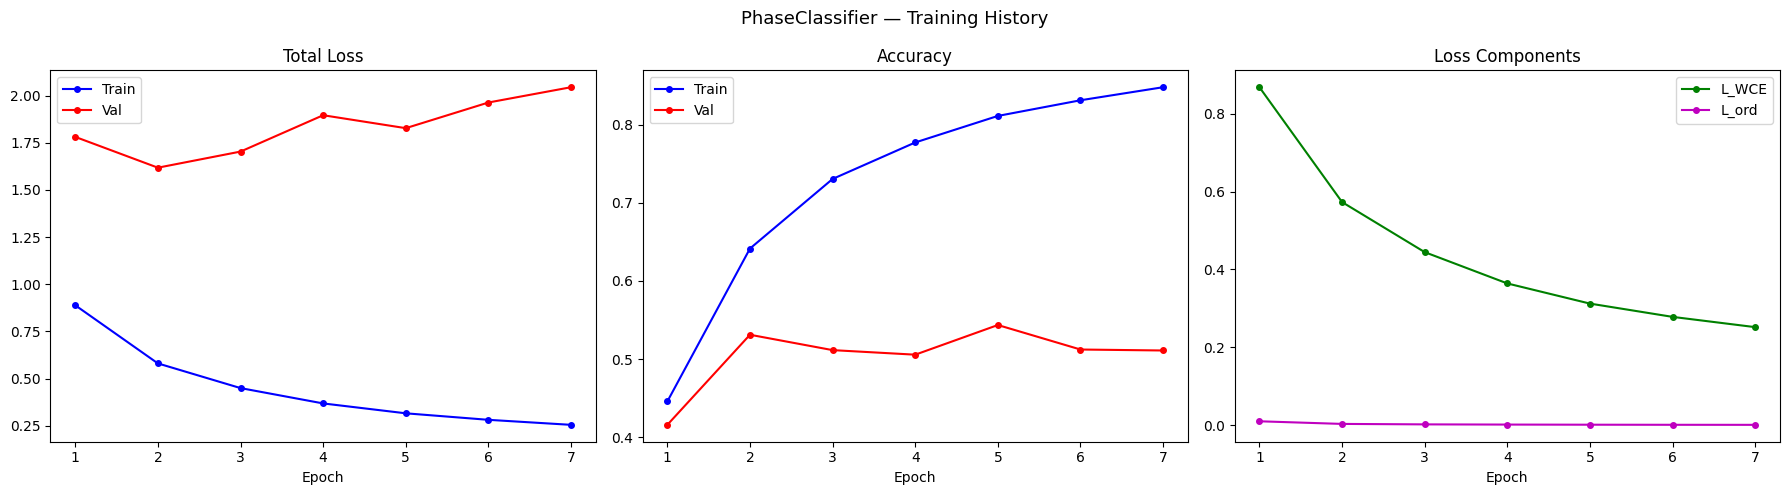

In [ ]:
ep_axis = range(1, len(train_log['tr_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(ep_axis, train_log['tr_loss'], 'b-o', markersize=4, label='Train')
axes[0].plot(ep_axis, train_log['va_loss'], 'r-o', markersize=4, label='Val')
axes[0].set_title('Total Loss');  axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(ep_axis, train_log['tr_acc'], 'b-o', markersize=4, label='Train')
axes[1].plot(ep_axis, train_log['va_acc'], 'r-o', markersize=4, label='Val')
axes[1].set_title('Accuracy');    axes[1].set_xlabel('Epoch'); axes[1].legend()
axes[2].plot(ep_axis, train_log['ce'],  'g-o', markersize=4, label='L_WCE')
axes[2].plot(ep_axis, train_log['ord'], 'm-o', markersize=4, label='L_ord')
axes[2].set_title('Loss Components'); axes[2].set_xlabel('Epoch'); axes[2].legend()
plt.suptitle('PhaseClassifier — Training History', fontsize=13)
plt.tight_layout()
plt.show()


## Test Set Evaluation

In [ ]:
_, test_acc, te_preds, te_true = run_eval(model, te_loader, loss_fn)

print(f"\n{'='*60}")
print(f"  Test Accuracy: {test_acc*100:.2f}%")
print(f"{'='*60}\n")

stage_names = [idx2cls[i] for i in range(N_CLASSES)]
print(classification_report(te_true, te_preds, labels=list(range(N_CLASSES)), target_names=stage_names, zero_division=0))


  Test Accuracy: 48.73%

              precision    recall  f1-score   support

          t2       0.62      0.64      0.63      2965
          t3       0.07      0.07      0.07       569
          t4       0.39      0.48      0.43      2859
          t5       0.07      0.03      0.04      1000
          t6       0.12      0.15      0.13       745
          t7       0.05      0.02      0.03      1226
          t8       0.32      0.59      0.42      3112
         t9+       0.66      0.49      0.56      6281
          tB       0.46      0.24      0.31      1272
         tEB       0.46      0.75      0.57      1690
         tHB       0.00      0.00      0.00         0
          tM       0.29      0.25      0.27      1967
        tPB2       0.28      0.75      0.41       393
        tPNa       0.87      0.78      0.82      4535
        tPNf       0.71      0.62      0.66       700
         tSB       0.48      0.22      0.30      1709

    accuracy                           0.49     31023


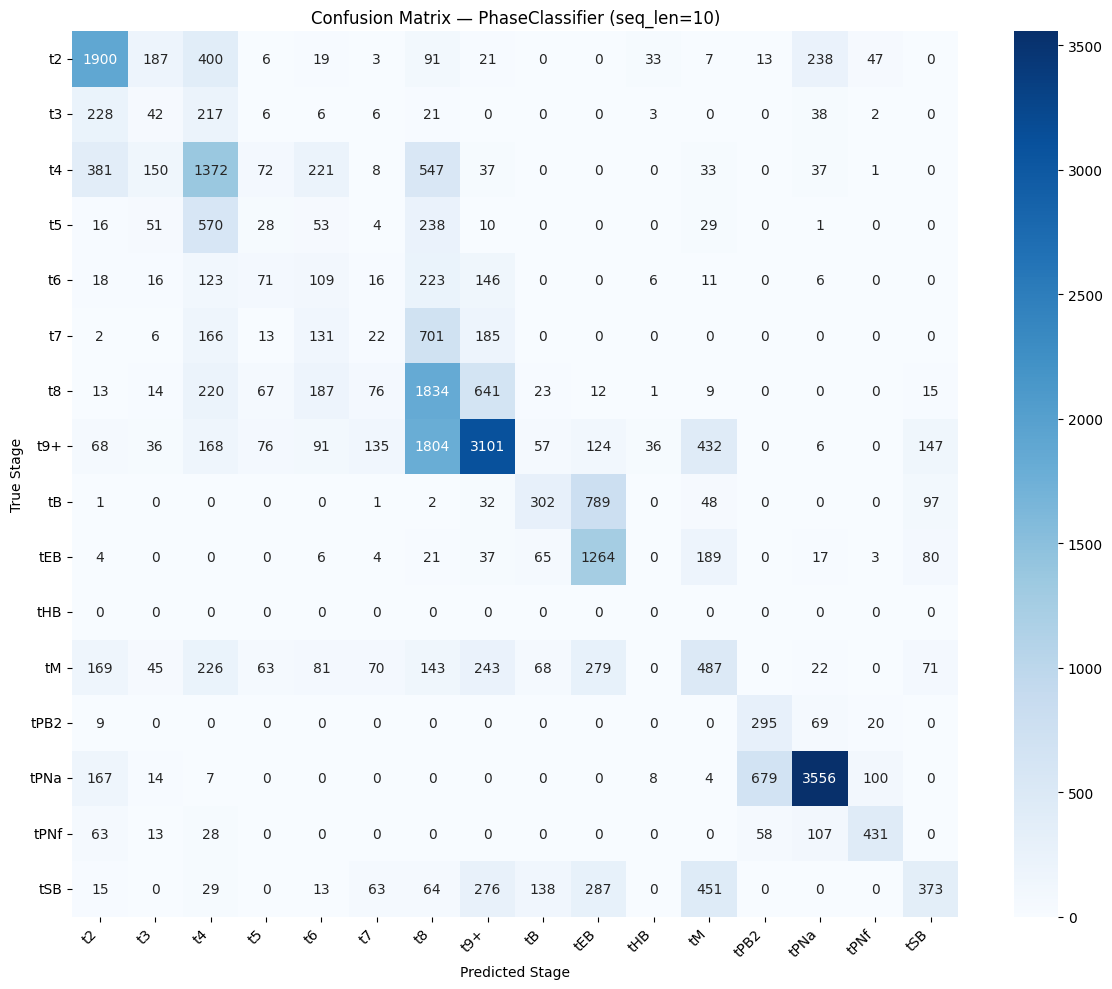

In [ ]:
cm = confusion_matrix(te_true, te_preds)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=stage_names, yticklabels=stage_names, ax=ax)
ax.set_xlabel('Predicted Stage')
ax.set_ylabel('True Stage')
ax.set_title(f'Confusion Matrix — PhaseClassifier (seq_len={SEQ_LEN})')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Final Summary

In [ ]:
print(f"{'='*62}")
print(f"  EMBRYO PHASE CLASSIFICATION — SUMMARY")
print(f"{'='*62}")
print()
print(f" Architecture")
print(f" Feature extractor : MobileNetV2 (ImageNet, frozen)")
print(f" Feature dim : {CNN_OUT_DIM}")
print(f" LSTM units : {LSTM_UNITS}")
print(f" LSTM layers : {NUM_LAYERS}")
print(f" Sequence length : {SEQ_LEN}")
print(f" Dropout rate : {DROP_RATE}")
print()
print(f" Data")
print(f" Videos used : {len(vid_frame_map)}")
print(f" Total frames : {len(frame_feats):,}")
print(f" Total sequences : {len(seq_pool):,}")
print(f" Train/Val/Test : {len(tr_seqs):,} / {len(va_seqs):,} / {len(te_seqs):,}")
print(f" Stage classes : {N_CLASSES}")
print()
print(f" Training")
print(f" Loss : L_WCE + {ORD_WEIGHT} × L_ord")
print(f" Optimiser : Adam (lr={LEARN_RATE}, wd={L2_REG})")
print(f" Epochs run : {len(train_log['tr_loss'])} / {MAX_EPOCHS}")
print(f" Early-stop window : {EARLY_STOP}")
print()
print(f" Results")
print(f" Test accuracy : {test_acc*100:.2f}%")
print()
print(f" Parameters")
print(f" LSTM + head : {trainable_params:,} (all trainable)")
print(f" CNN backbone : ~3.5 M (frozen, not counted)")
print(f"{'='*62}")


  EMBRYO PHASE CLASSIFICATION — SUMMARY

  Architecture
    Feature extractor : MobileNetV2 (ImageNet, frozen)
    Feature dim       : 1280
    LSTM units        : 256
    LSTM layers       : 3
    Sequence length   : 10
    Dropout rate      : 0.3

  Data
    Videos used       : 500
    Total frames      : 212,224
    Total sequences   : 207,724
    Train/Val/Test    : 147,040 / 29,661 / 31,023
    Stage classes     : 16

  Training
    Loss              : L_WCE + 2.0 × L_ord
    Optimiser         : Adam (lr=0.001, wd=1e-05)
    Epochs run        : 7 / 20
    Early-stop window : 5

  Results
    Test accuracy     : 48.73%

  Parameters
    LSTM + head       : 2,631,696 (all trainable)
    CNN backbone      : ~3.5 M (frozen, not counted)
